In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/WEEK3.csv')

In [3]:
df.head()

,_unit_id,_golden,_unit_state,_trusted_judgments,policies_violated,city,review
0,679455653,False,finalized,3,RudeService\nOrderProblem\nFilthy,"Av. de Monforte de Lemos, 12, Madrid, Spain","I'm not a huge mcds lover, but I've been to be..."
1,679455654,False,finalized,3,RudeService,"Av. de Monforte de Lemos, 12, Madrid, Spain",Terrible customer service. ξI came in at 9:30p...
2,679455655,False,finalized,3,SlowService\nOrderProblem,"Av. de Monforte de Lemos, 12, Madrid, Spain","First they ""lost"" my order, actually they gave..."
3,679455656,False,finalized,3,na,"Av. de Monforte de Lemos, 12, Madrid, Spain",I see I'm not the only one giving 1 star. Only...
4,679455657,False,finalized,3,RudeService,"Av. de Monforte de Lemos, 12, Madrid, Spain","Well, it's Sabores Ibéricos's, so you know wha..."


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1525 entries, 0 to 1524
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   _unit_id            1525 non-null   int64 
 1   _golden             1525 non-null   bool  
 2   _unit_state         1525 non-null   object
 3   _trusted_judgments  1525 non-null   int64 
 4   policies_violated   1525 non-null   object
 5   city                1438 non-null   object
 6   review              1525 non-null   object
dtypes: bool(1), int64(2), object(4)
memory usage: 73.1+ KB


In [5]:
df.shape

(1525, 7)

Data Dictionary

Here's a breakdown of the columns in the dataset and their likely meanings:

_unit_id: A unique identifier for each review/row in the dataset. This is likely an internal system ID.

_golden: A boolean flag (True/False) indicating if the record is a 'golden' record, often used for quality control or training data.

_unit_state: The current state of the unit, such as 'finalized' as seen in the sample, indicating its processing status.

_trusted_judgments: An integer indicating the number of trusted judgments or evaluations received for this particular record, often used in crowdsourcing or data labeling.

policies_violated: This column contains text describing which policies were violated by the service or business being reviewed. Multiple violations can be listed, separated by '\n'. 'na' likely stands for 'not applicable' or no violations.

city: The city and full address of the location being reviewed.

review: The actual text content of the customer review.

In [6]:
df.isna().sum()

,0
_unit_id,0
_golden,0
_unit_state,0
_trusted_judgments,0
policies_violated,0
city,87
review,0


In [7]:
df['_unit_state'].unique()

array(['finalized'], dtype=object)

In [8]:
df['_trusted_judgments'].unique()

array([3])

In [9]:
df['city'].unique()

array(['Av. de Monforte de Lemos, 12, Madrid, Spain',
       'San Sebastián de los Reyes',
       'Calle de Alonso Cano 32, Madrid, Spain',
       'Paseo de la Castellana, 200, Madrid, Spain',
       'Calle Albacete 10, Madrid, Spain',
       'Nu�ez de Balboa 118, Madrid, Spain',
       'Calle Campezo, 20, 28022 Madrid, Espa�a',
       'Calle de Gran Via, 100, 28027 Madrid, Espa�a',
       'Calle de Bravo Murillo, 380, Madrid, Spain', nan], dtype=object)

In [10]:
# CHECKING IF THE REVIEWS HAVE NAMES OF CITIES MENTIONED IN IT, SO AS TO PICK IT FROM THERE NAND FILL THE NAs
# Get a list of unique city names (excluding NaN) to search for
known_cities = df['city'].dropna().unique()

# Filter for rows where 'city' is NaN
missing_city_df = df[df['city'].isna()]

# Function to check if any known city name is in the review
def find_city_in_review(review_text, cities_list):
    found_cities = []
    for city in cities_list:
        # Simple string matching, case-insensitive
        if pd.isna(review_text):
            continue
        if city.lower() in review_text.lower():
            found_cities.append(city)
    return found_cities if found_cities else 'No city mentioned'

# Apply the function to the reviews with missing cities
missing_city_df['found_cities_in_review'] = missing_city_df['review'].apply(lambda x: find_city_in_review(x, known_cities))

# Display the rows where cities were found or not found
display(missing_city_df[['review', 'found_cities_in_review']])

/tmp/ipykernel_11631/2458863964.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  missing_city_df['found_cities_in_review'] = missing_city_df['review'].apply(lambda x: find_city_in_review(x, known_cities))


,review,found_cities_in_review
1413,"Sorry, ξam I bothering you? ξWorst customer se...",No city mentioned
1414,Ran in for a quick breakfast. Ordered the peti...,No city mentioned
1415,It's pretty bad. They've messed my order up tw...,No city mentioned
1416,Kids working drive thru have no idea what they...,No city mentioned
1417,We were pressed for time to see a movie at 12:...,No city mentioned
...,...,...
1495,"very good Sabores Ibéricos's ,good service",No city mentioned
1496,Came here for the McCafe.Coffee was a little l...,No city mentioned
1497,I actually got in an accident trying to leave ...,No city mentioned
1498,Came here for breakfast and there was total ch...,No city mentioned


In [11]:
# Drop rows where 'city' is NaN
df_cleaned = df.dropna(subset=['city'])

# Display the new shape of the DataFrame to confirm the rows were dropped
print(f"Original DataFrame shape: {df.shape}")
print(f"Cleaned DataFrame shape (after dropping NaNs in 'city'): {df_cleaned.shape}")

# Optionally, update the original df variable if you want to continue with the cleaned data
df = df_cleaned.copy()

Original DataFrame shape: (1525, 7)
Cleaned DataFrame shape (after dropping NaNs in 'city'): (1438, 7)


In [12]:
df_copy = df.copy()
df_copy.head()

,_unit_id,_golden,_unit_state,_trusted_judgments,policies_violated,city,review
0,679455653,False,finalized,3,RudeService\nOrderProblem\nFilthy,"Av. de Monforte de Lemos, 12, Madrid, Spain","I'm not a huge mcds lover, but I've been to be..."
1,679455654,False,finalized,3,RudeService,"Av. de Monforte de Lemos, 12, Madrid, Spain",Terrible customer service. ξI came in at 9:30p...
2,679455655,False,finalized,3,SlowService\nOrderProblem,"Av. de Monforte de Lemos, 12, Madrid, Spain","First they ""lost"" my order, actually they gave..."
3,679455656,False,finalized,3,na,"Av. de Monforte de Lemos, 12, Madrid, Spain",I see I'm not the only one giving 1 star. Only...
4,679455657,False,finalized,3,RudeService,"Av. de Monforte de Lemos, 12, Madrid, Spain","Well, it's Sabores Ibéricos's, so you know wha..."


In [13]:
import nltk
import spacy

In [14]:
from nltk.corpus import stopwords

In [15]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [16]:
!python -m spacy download en_core_web_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 74.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [17]:
stop_words = set(stopwords.words('english'))
sw = spacy.load('en_core_web_md')

spacy_stopwords = sw.Defaults.stop_words

In [18]:
import re #regular expression

def clean_text (text):
  text = str(text)
  text = re.sub(r'@["A-Za-z0-9"]+', '', text) #removing @mentions
  text = re.sub(r'#', '', text) #removing the # symbol
  text = re.sub(r'RT[\s]+', '', text)  #removing retweets
  return text

#Remove nltk stopwords
def rem_en (input_text):
  input_text = str (input_text)
  words = input_text.lower().split()
  noise_free_words = [word for word in words if word not in stop_words]
  noise_free_text = " ".join(noise_free_words)
  return noise_free_text

def rem_spacy(input_text):
  input_text = str(input_text)
  words = input_text.lower().split()
  # Filter words that start with an alphabet and are not spacy stopwords
  noise_free_words = [word for word in words if word and word[0].isalpha() and word.lower() not in spacy_stopwords]
  noise_free_text = " ".join(noise_free_words)
  return noise_free_text

In [19]:
df['review'] = df['review'].apply(clean_text)
df['review'] = df['review'].apply(rem_en)
df['review'] = df['review'].apply(rem_spacy)

display(df[['review']].head())

,review
0,"huge mcds lover, better ones. far worst too! f..."
1,terrible customer service. ξi came stood regis...
2,"order, actually gave took minutes figure waiti..."
3,giving star. star!!! that's need say!
4,"well, sabores ibéricos's, know food is. ξthis ..."


Saved plots/word_cloud_reviews.png


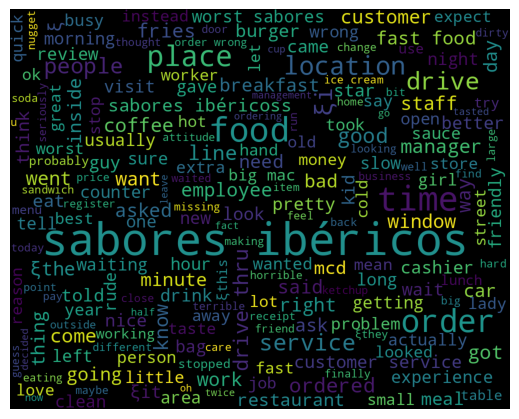

In [25]:
#Import word cloud library
from wordcloud import WordCloud

#initialize it with how the plot should be
def plot_wordcloud(text):
  wordcloud_instance = WordCloud(background_color = 'black',
                        width = 1000, height = 800,
                        stopwords = None,
                        min_font_size = 10).generate(str(text))
  plt.figure(figsize = (5,5),facecolor= None)
  plt.imshow(wordcloud_instance)
  plt.axis("off")
  plt.tight_layout(pad = 0)
  save_plot(plt.gcf(), 'word_cloud_reviews') # Save the word cloud plot
  plt.show()

text = ' '
#itirate throught the rows and put them together in one row
for index, item in df.iterrows():
  text = text + ' '+ item['review']

# the more common the word, the bigger it is

#call the function
plot_wordcloud(text)

In [21]:
# COUNT OF POLICIES VIOLATED
import pandas as pd

# Split the 'policies_violated' column by '\n' to get individual policies
all_policies = df['policies_violated'].str.split('\n', expand=True).stack()

# Remove 'na' entries if they exist, as they represent no violations
all_policies = all_policies[all_policies != 'na']

# Calculate the frequency of each policy
policy_counts = all_policies.value_counts()

# Get the top 5 most frequent policies
all_policies = policy_counts.head(10)

# Display all the policies and their counts
print("frequent policies violated:")
display(all_policies)

frequent policies violated:


,count
RudeService,480
SlowService,344
OrderProblem,319
BadFood,255
ScaryMcDs,138
Filthy,127
MissingFood,55
Cost,53


The analysis of the `policies_violated` column reveals the most common issues reported in the reviews. Understanding these frequent violations can help identify key areas for improvement in service or operations. The 'na' entries, representing no violations, have been excluded from this analysis to focus on actual policy breaches.

Saved plots/frequent_policies_violated.png


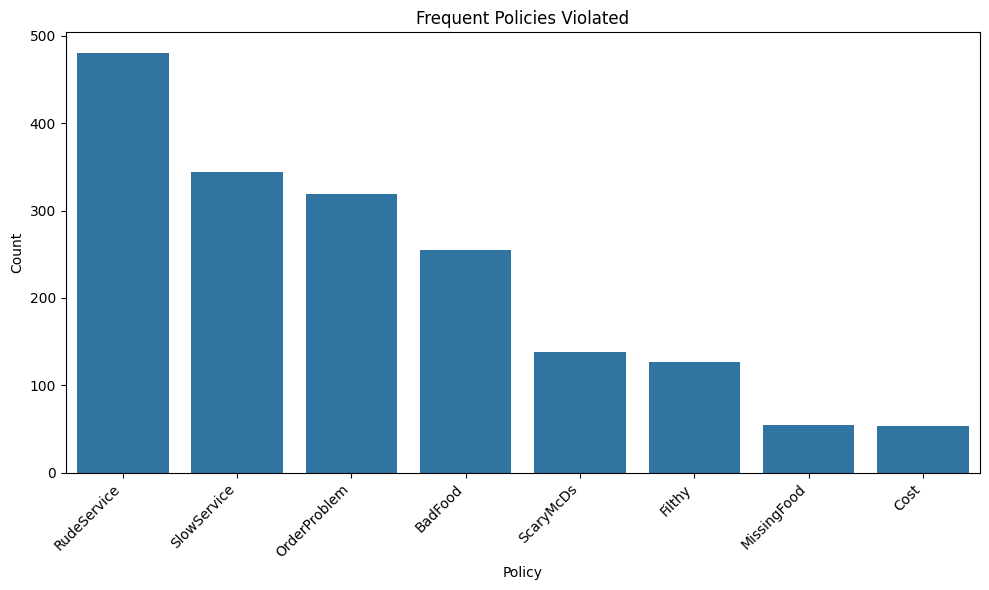

In [26]:
plt.figure(figsize=(10, 6))
sns.barplot(x=all_policies.index, y=all_policies.values)
plt.title('Frequent Policies Violated')
plt.xlabel('Policy')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
save_plot(plt.gcf(), 'frequent_policies_violated')
plt.show()

In [43]:
# COUNT OF POLICY VIOLATED BY CITY
# Expand 'policies_violated' into individual rows for analysis per city
expanded_policies = sentiment_df.assign(policies_violated=sentiment_df['policies_violated'].str.split('\n')).explode('policies_violated')

# Filter out 'na' entries as they represent no violations
filtered_policies = expanded_policies[expanded_policies['policies_violated'] != 'na']

# Group by city and policies_violated, then count
violations_by_city = filtered_policies.groupby(['city', 'policies_violated']).size().unstack(fill_value=0)

# Display the results
print("Count of policies violated by address:")
display(violations_by_city)

Count of policies violated by address:


policies_violated,BadFood,Cost,Filthy,MissingFood,OrderProblem,RudeService,ScaryMcDs,SlowService
city,,,,,,,,
"Av. de Monforte de Lemos, 12, Madrid, Spain",28,3,16,5,28,38,8,40
"Calle Albacete 10, Madrid, Spain",26,8,15,6,51,65,33,50
"Calle Campezo, 20, 28022 Madrid, Espa�a",24,3,16,6,19,37,3,29
"Calle de Alonso Cano 32, Madrid, Spain",14,5,7,3,18,25,10,14
"Calle de Bravo Murillo, 380, Madrid, Spain",34,6,21,6,19,62,24,36
"Calle de Gran Via, 100, 28027 Madrid, Espa�a",18,5,9,8,40,48,27,49
"Nu�ez de Balboa 118, Madrid, Spain",5,3,6,6,20,30,1,27
"Paseo de la Castellana, 200, Madrid, Spain",26,5,7,1,21,30,7,10
San Sebastián de los Reyes,80,15,30,14,103,145,25,89


Saved plots/policies_by_city_subplots_for_ppt.png


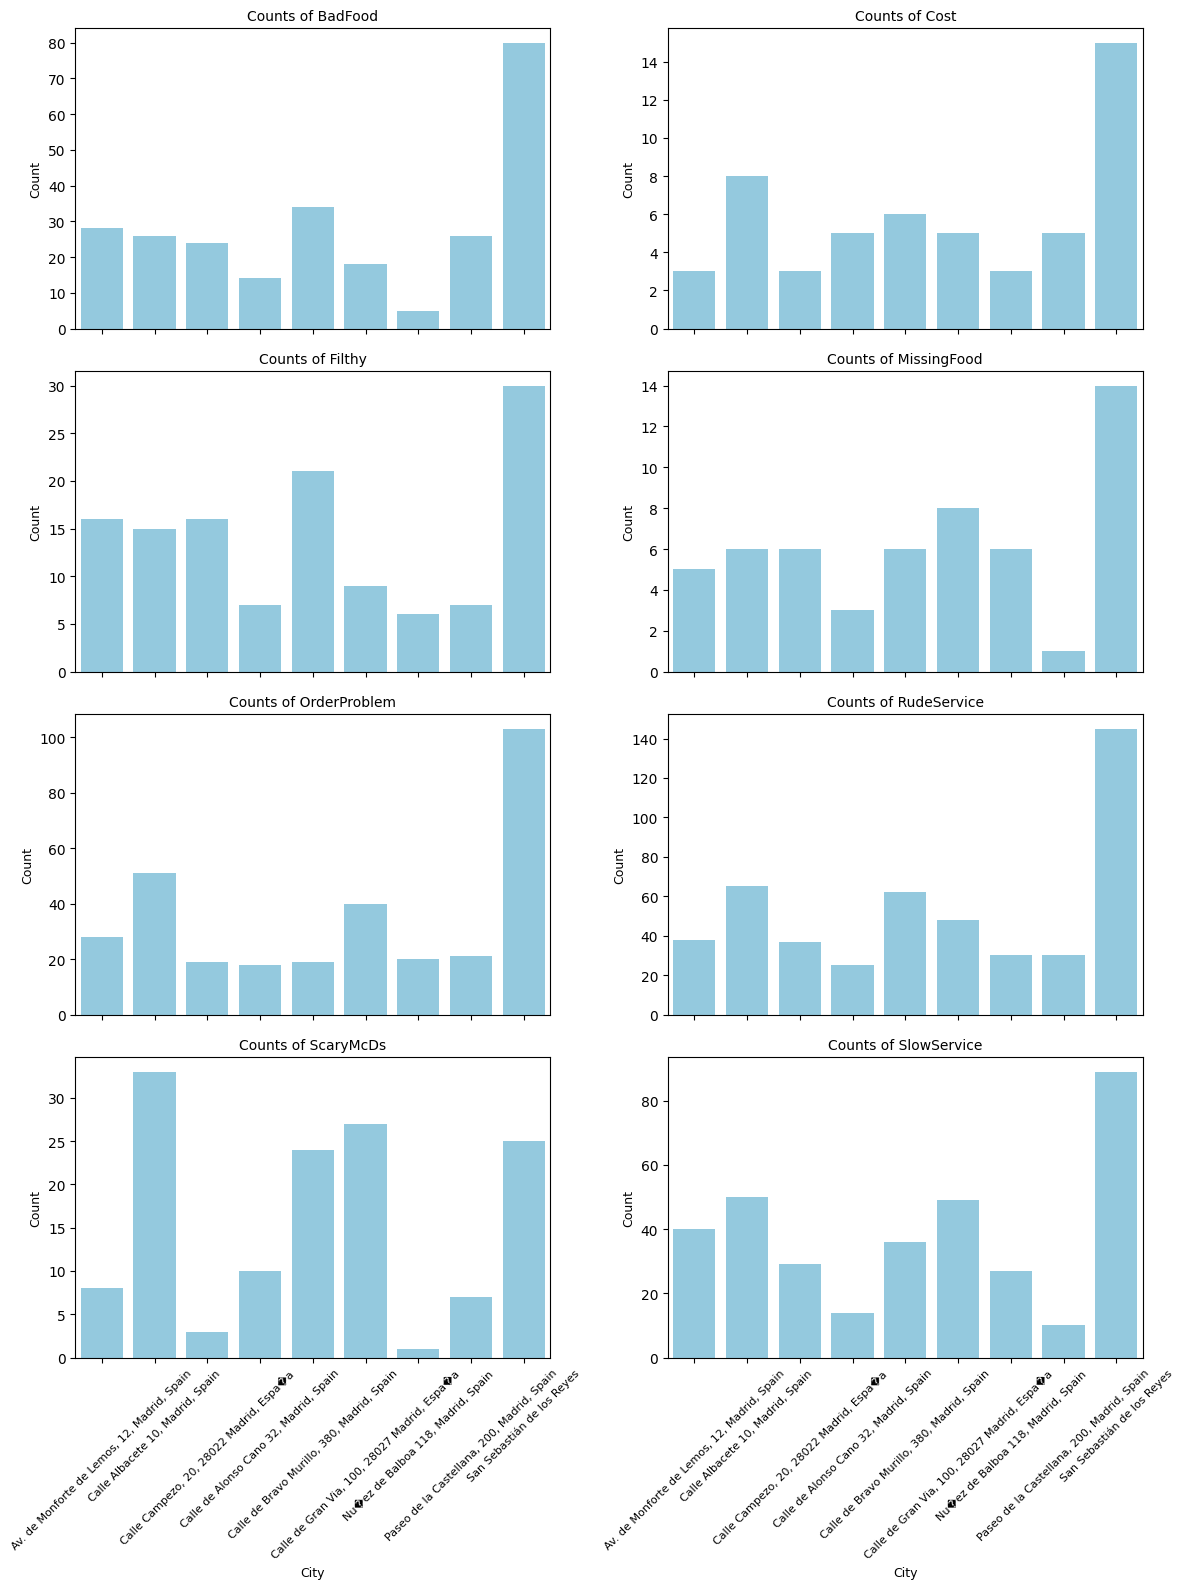

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the list of policies (columns in violations_by_city)
policies = violations_by_city.columns

# Determine the number of rows and columns for the subplots
num_policies = len(policies)
num_cols = 2 # Fixed to 2 columns for a more consistent layout
num_rows = (num_policies + num_cols - 1) // num_cols # Calculate rows needed

# Adjust figure size for presentation slides (reduced width and height per row)
# Increased figure width and height factor to better accommodate long city names
fig_policy_by_city, axes_policy_by_city = plt.subplots(num_rows, num_cols, figsize=(12, num_rows * 4)) # Increased width to 12, height factor to 4
axes_policy_by_city = axes_policy_by_city.flatten() # Flatten for easy iteration

for i, policy in enumerate(policies):
    sns.barplot(x=violations_by_city[policy].index, y=violations_by_city[policy].values, ax=axes_policy_by_city[i], color='skyblue')
    axes_policy_by_city[i].set_title(f'Counts of {policy}', fontsize=10) # Smaller title font
    axes_policy_by_city[i].set_ylabel('Count', fontsize=9) # Smaller label font
    # Explicitly set horizontal alignment to 'right' for 45-degree rotation
    axes_policy_by_city[i].tick_params(axis='x', rotation=45, labelsize=8) # Removed 'ha' argument

    # Remove x-axis label and tick labels for all but the last row
    if i < num_policies - num_cols: # Check if it's not in the last row
        axes_policy_by_city[i].set_xlabel('')
        axes_policy_by_city[i].tick_params(axis='x', labelbottom=False) # Hide x-axis tick labels
    else:
        axes_policy_by_city[i].set_xlabel('City', fontsize=9) # Keep x-axis label for last row

# Hide any unused subplots
for j in range(i + 1, num_rows * num_cols):
    fig_policy_by_city.delaxes(axes_policy_by_city[j])

plt.tight_layout()
save_plot(fig_policy_by_city, 'policies_by_city_subplots_for_ppt') # Save with a new, presentation-friendly name
plt.show()

In [45]:
# Calculate the total count of policies violated for each city
total_violations_by_city = violations_by_city.sum(axis=1)

print("Total count of policies violated by city:")
display(total_violations_by_city)

Total count of policies violated by city:


,0
city,
"Av. de Monforte de Lemos, 12, Madrid, Spain",166
"Calle Albacete 10, Madrid, Spain",254
"Calle Campezo, 20, 28022 Madrid, Espa�a",137
"Calle de Alonso Cano 32, Madrid, Spain",96
"Calle de Bravo Murillo, 380, Madrid, Spain",208
"Calle de Gran Via, 100, 28027 Madrid, Espa�a",204
"Nu�ez de Balboa 118, Madrid, Spain",98
"Paseo de la Castellana, 200, Madrid, Spain",107
San Sebastián de los Reyes,501


/tmp/ipykernel_11631/2673383073.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_violations.index, y=sorted_violations.values, palette='viridis')


Saved plots/total_violations_by_city.png


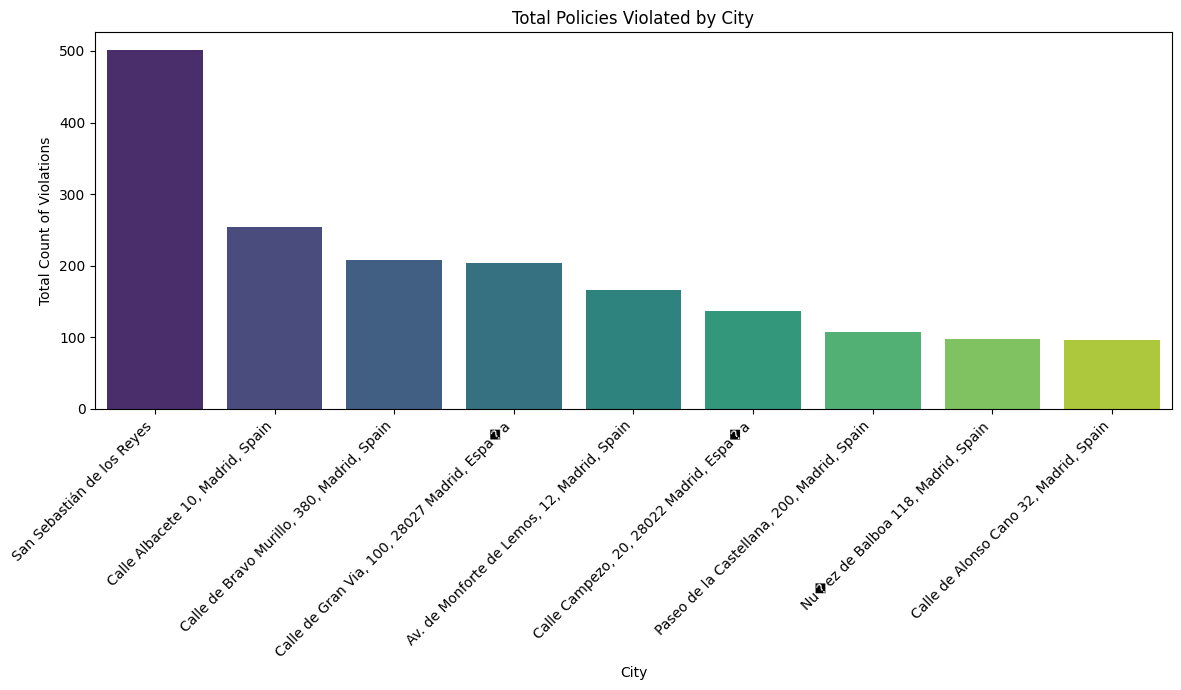

In [46]:
# Sort the values for better visualization
sorted_violations = total_violations_by_city.sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=sorted_violations.index, y=sorted_violations.values, palette='viridis')
plt.title('Total Policies Violated by City')
plt.xlabel('City')
plt.ylabel('Total Count of Violations')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
save_plot(plt.gcf(), 'total_violations_by_city')
plt.show()

In [31]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 7.2 MB/s eta 0:00:00


In [32]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from tqdm import tqdm

sia = SentimentIntensityAnalyzer()

In [34]:
result = {}
for i, row in tqdm(df.iterrows(), total=len(df)):
  user_review = str(row['review']) # this ensures review is a string
  review_id = row.name
  # calculate sentiment score and store them in the dictionary
  result[review_id] = sia.polarity_scores(user_review)

100%|██████████| 1438/1438 [00:01<00:00, 1129.43it/s]


In [35]:
sentiment = pd.DataFrame(result).T

sentiment.head()

,neg,neu,pos,compound
0,0.333,0.308,0.358,0.2242
1,0.237,0.661,0.102,-0.7430
2,0.141,0.789,0.070,-0.5994
3,0.000,0.584,0.416,0.5526
4,0.123,0.613,0.265,0.8934


In [36]:
sentiment_df = pd.concat([df, sentiment], axis=1)
sentiment_df.head(20)

,_unit_id,_golden,_unit_state,_trusted_judgments,policies_violated,city,review,neg,neu,pos,compound
0,679455653,False,finalized,3,RudeService\nOrderProblem\nFilthy,"Av. de Monforte de Lemos, 12, Madrid, Spain","huge mcds lover, better ones. far worst too! f...",0.333,0.308,0.358,0.2242
1,679455654,False,finalized,3,RudeService,"Av. de Monforte de Lemos, 12, Madrid, Spain",terrible customer service. ξi came stood regis...,0.237,0.661,0.102,-0.7430
2,679455655,False,finalized,3,SlowService\nOrderProblem,"Av. de Monforte de Lemos, 12, Madrid, Spain","order, actually gave took minutes figure waiti...",0.141,0.789,0.070,-0.5994
3,679455656,False,finalized,3,na,"Av. de Monforte de Lemos, 12, Madrid, Spain",giving star. star!!! that's need say!,0.000,0.584,0.416,0.5526
4,679455657,False,finalized,3,RudeService,"Av. de Monforte de Lemos, 12, Madrid, Spain","well, sabores ibéricos's, know food is. ξthis ...",0.123,0.613,0.265,0.8934
5,679455658,False,finalized,3,BadFood\nSlowService,"Av. de Monforte de Lemos, 12, Madrid, Spain",worst slowest sabores ibéricos's franchises is...,0.244,0.756,0.000,-0.7003
6,679455659,False,finalized,3,SlowService\nScaryMcDs,"Av. de Monforte de Lemos, 12, Madrid, Spain",crazy sabores ibéricos's. ξthis primarily slow...,0.151,0.806,0.043,-0.7351
7,679455660,False,finalized,3,RudeService,"Av. de Monforte de Lemos, 12, Madrid, Spain",star beng kind. blame management. day free cof...,0.119,0.685,0.196,0.8125
8,679455661,False,finalized,3,SlowService\nRudeService\nMissingFood,"Av. de Monforte de Lemos, 12, Madrid, Spain",upset fast food drive service till came sabore...,0.168,0.798,0.034,-0.8906
9,679455662,False,finalized,3,na,"Av. de Monforte de Lemos, 12, Madrid, Spain",sabores ibéricos's gotten better. usually orde...,0.051,0.740,0.209,0.9222


In [37]:
# Define a function to categorize sentiment based on the compound score
def categorize_sentiment(compound_score):
    if compound_score >= 0.05:
        return 'Positive'
    elif compound_score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Apply the function to create a new 'sentiment_category' column
sentiment_df['sentiment_category'] = sentiment_df['compound'].apply(categorize_sentiment)

# Calculate the proportion of each sentiment category
sentiment_proportions = sentiment_df['sentiment_category'].value_counts(normalize=True) * 100

print("Proportion of each sentiment category:")
display(sentiment_proportions)

Proportion of each sentiment category:


,proportion
sentiment_category,
Positive,48.052851
Negative,46.175243
Neutral,5.771905


/tmp/ipykernel_11631/3828379038.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_proportions.index, y=sentiment_proportions.values, palette='coolwarm')


Saved plots/overall_sentiment_proportions.png


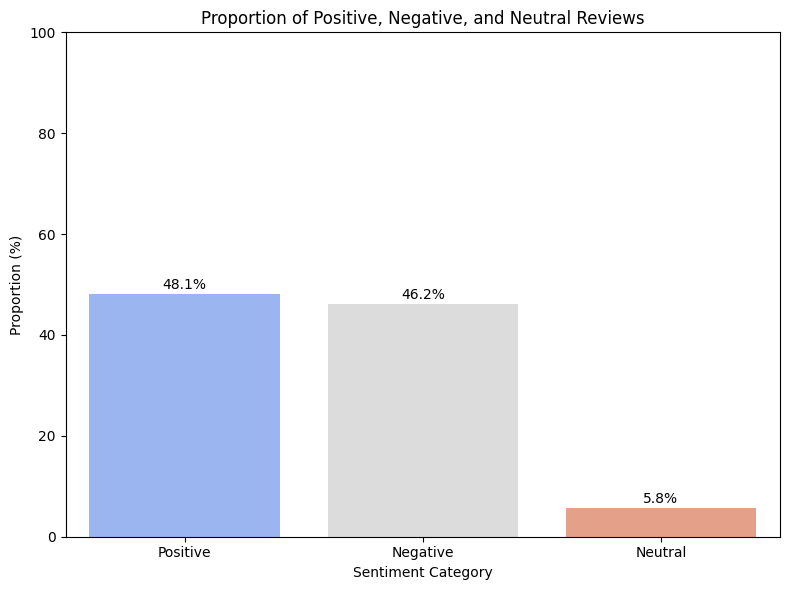

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_proportions.index, y=sentiment_proportions.values, palette='coolwarm')
plt.title('Proportion of Positive, Negative, and Neutral Reviews')
plt.xlabel('Sentiment Category')
plt.ylabel('Proportion (%)')
plt.ylim(0, 100) # Ensure y-axis goes from 0 to 100

# Add percentage labels on top of the bars
for index, value in enumerate(sentiment_proportions.values):
    plt.text(index, value + 1, f'{value:.1f}%', ha='center')

plt.tight_layout()
save_plot(plt.gcf(), 'overall_sentiment_proportions')
plt.show()

In [39]:
# Group by city and sentiment category, then count occurrences
sentiment_by_city = sentiment_df.groupby(['city', 'sentiment_category']).size().unstack(fill_value=0)

# Calculate proportions within each city
sentiment_by_city_proportion = sentiment_by_city.apply(lambda x: x / x.sum(), axis=1)

print("Sentiment distribution by city (proportions):")
display(sentiment_by_city_proportion.head())

Sentiment distribution by city (proportions):


sentiment_category,Negative,Neutral,Positive
city,,,
"Av. de Monforte de Lemos, 12, Madrid, Spain",0.407692,0.061538,0.530769
"Calle Albacete 10, Madrid, Spain",0.474886,0.036530,0.488584
"Calle Campezo, 20, 28022 Madrid, Espa�a",0.523810,0.047619,0.428571
"Calle de Alonso Cano 32, Madrid, Spain",0.386667,0.026667,0.586667
"Calle de Bravo Murillo, 380, Madrid, Spain",0.448485,0.054545,0.496970


Saved plots/sentiment_distribution_by_city.png


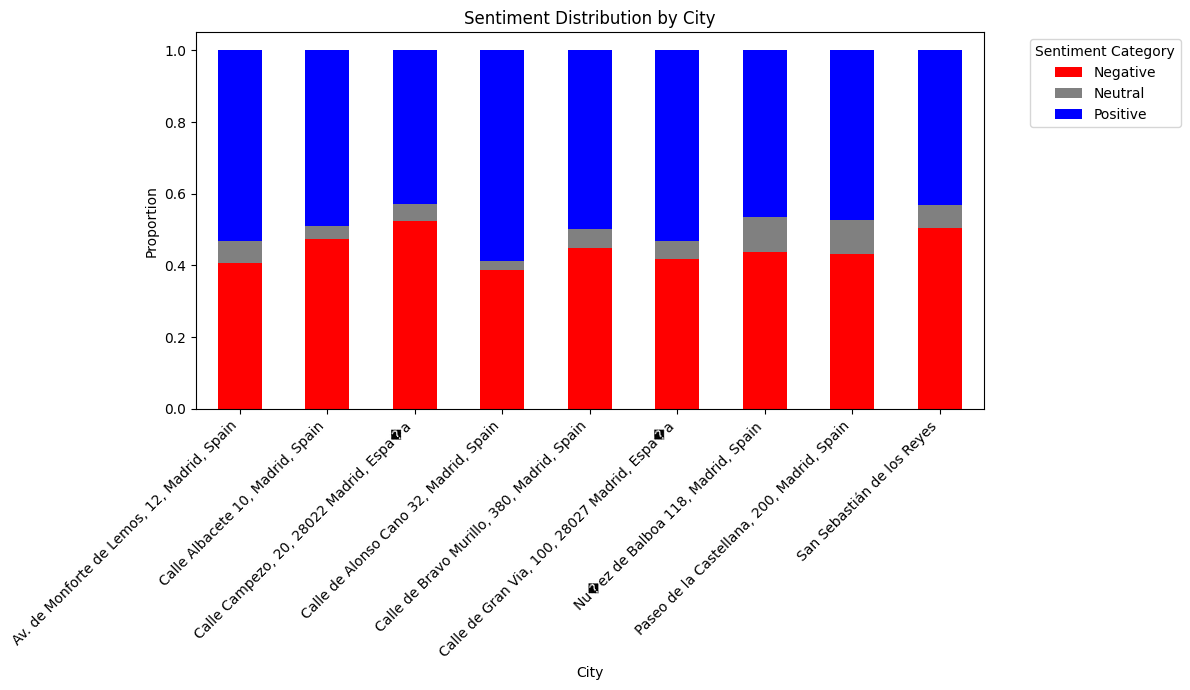

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define custom colors: Red for Negative, Grey for Neutral, Blue for Positive
custom_colors = ['red', 'grey', 'blue']

# Plotting the stacked bar chart with custom colors
fig_sentiment_by_city = sentiment_by_city_proportion.plot(kind='bar', stacked=True, figsize=(12, 7), color=custom_colors)
plt.title('Sentiment Distribution by City')
plt.xlabel('City')
plt.ylabel('Proportion')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
save_plot(fig_sentiment_by_city.figure, 'sentiment_distribution_by_city')
plt.show()

City Analysis DataFrame (Features and Target for Regression):


,city,total_violations,proportion_negative_reviews
0,"Av. de Monforte de Lemos, 12, Madrid, Spain",166,0.407692
1,"Calle Albacete 10, Madrid, Spain",254,0.474886
2,"Calle Campezo, 20, 28022 Madrid, Espa�a",137,0.523810
3,"Calle de Alonso Cano 32, Madrid, Spain",96,0.386667
4,"Calle de Bravo Murillo, 380, Madrid, Spain",208,0.448485
5,"Calle de Gran Via, 100, 28027 Madrid, Espa�a",204,0.419162
6,"Nu�ez de Balboa 118, Madrid, Spain",98,0.436620
7,"Paseo de la Castellana, 200, Madrid, Spain",107,0.432990
8,San Sebastián de los Reyes,501,0.503667



Linear Regression Model Coefficients:
Intercept: -459.4515
Coefficient for Proportion Negative Reviews: 1464.0793

Mean Absolute Error (MAE): 73.4179
R-squared (R2): 0.2693

City-wise Actual vs. Predicted Total Violations (Risk Score):


,city,total_violations,proportion_negative_reviews,predicted_total_violations
0,"Av. de Monforte de Lemos, 12, Madrid, Spain",166,0.407692,137.442387
1,"Calle Albacete 10, Madrid, Spain",254,0.474886,235.819054
2,"Calle Campezo, 20, 28022 Madrid, Espa�a",137,0.523810,307.447199
3,"Calle de Alonso Cano 32, Madrid, Spain",96,0.386667,106.659181
4,"Calle de Bravo Murillo, 380, Madrid, Spain",208,0.448485,197.165902
5,"Calle de Gran Via, 100, 28027 Madrid, Espa�a",204,0.419162,154.234453
6,"Nu�ez de Balboa 118, Madrid, Spain",98,0.436620,179.794410
7,"Paseo de la Castellana, 200, Madrid, Spain",107,0.432990,174.479762
8,San Sebastián de los Reyes,501,0.503667,277.957652


Saved plots/regression_negative_reviews_vs_violations.png


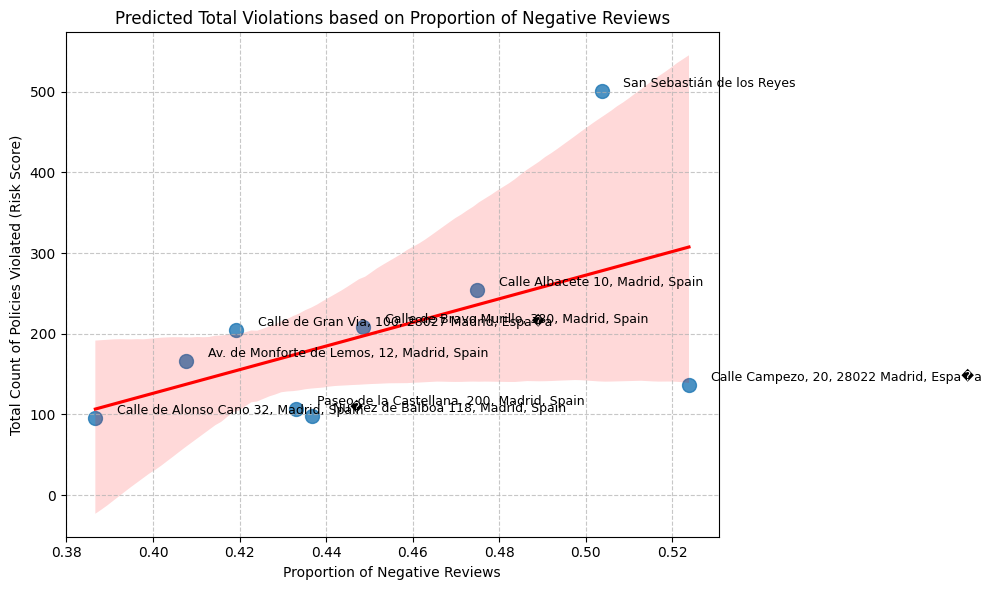


Note: Due to the extremely limited number of data points (cities), this model serves primarily as a conceptual demonstration of how a linear relationship *could* be explored. Robust predictive models typically require significantly more data.


In [47]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Features per City
# Combine total violations and negative sentiment proportion into a single DataFrame
city_analysis_df = pd.DataFrame(total_violations_by_city)
city_analysis_df = city_analysis_df.rename(columns={0: 'total_violations'})
city_analysis_df['proportion_negative_reviews'] = sentiment_by_city_proportion['Negative']

# Reset index to make 'city' a regular column
city_analysis_df = city_analysis_df.reset_index()
city_analysis_df = city_analysis_df.rename(columns={'index': 'city'})

print("City Analysis DataFrame (Features and Target for Regression):")
display(city_analysis_df)

# 2. Define Features (X) and Target (y)
X = city_analysis_df[['proportion_negative_reviews']] # Feature
y = city_analysis_df['total_violations']             # Target (Risk Score)

# 3. Train Linear Regression Model
model = LinearRegression()
model.fit(X, y)

# 4. Make Predictions
city_analysis_df['predicted_total_violations'] = model.predict(X)

# 5. Display Model Results
print("\nLinear Regression Model Coefficients:")
print(f"Intercept: {model.intercept_:.4f}")
print(f"Coefficient for Proportion Negative Reviews: {model.coef_[0]:.4f}")

# Calculate and print MAE and R2
mae = mean_absolute_error(y, city_analysis_df['predicted_total_violations'])
r2 = r2_score(y, city_analysis_df['predicted_total_violations'])
print(f"\nMean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R2): {r2:.4f}")

print("\nCity-wise Actual vs. Predicted Total Violations (Risk Score):")
display(city_analysis_df[['city', 'total_violations', 'proportion_negative_reviews', 'predicted_total_violations']])

# 6. Visualize the Regression
plt.figure(figsize=(10, 6))
sns.regplot(x='proportion_negative_reviews', y='total_violations', data=city_analysis_df, scatter_kws={'s': 100}, line_kws={'color': 'red'})
for i, row in city_analysis_df.iterrows():
    plt.text(row['proportion_negative_reviews'] + 0.005, row['total_violations'] + 5, row['city'], fontsize=9, rotation=0)
plt.title('Predicted Total Violations based on Proportion of Negative Reviews')
plt.xlabel('Proportion of Negative Reviews')
plt.ylabel('Total Count of Policies Violated (Risk Score)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
save_plot(plt.gcf(), 'regression_negative_reviews_vs_violations')
plt.show()

print("\nNote: Due to the extremely limited number of data points (cities), this model serves primarily as a conceptual demonstration of how a linear relationship *could* be explored. Robust predictive models typically require significantly more data.")

In [42]:
!zip -r /content/plots.zip /content/plots
print("Your plots have been zipped to /content/plots.zip. You can download this file from the Colab file browser.")

  adding: content/plots/ (stored 0%)
  adding: content/plots/frequent_policies_violated.png (deflated 24%)
  adding: content/plots/overall_sentiment_proportions.png (deflated 28%)
  adding: content/plots/word_cloud_reviews.png (deflated 0%)
  adding: content/plots/sentiment_distribution_by_city.png (deflated 17%)
Your plots have been zipped to /content/plots.zip. You can download this file from the Colab file browser.


In [23]:
import os

def save_plot(fig, filename):
    """Saves a matplotlib figure to the 'plots' directory."""
    if not os.path.exists('plots'):
        os.makedirs('plots')
    fig.savefig(f'plots/{filename}.png', bbox_inches='tight', dpi=300)
    print(f"Saved plots/{filename}.png")
